# Univariate Analysis
### Deep-Dive Single-Variable Exploration for Machine Learning

---

### Scope & Focus of This Notebook
- **Primary Topic**: Univariate Exploratory Data Analysis (EDA) — analyzing one feature at a time in isolation.
- **What You Will Learn**:
  1. Categorical variables: Frequency distributions, count plots (`sns.countplot`), proportion bar charts, donut charts, and Pareto analysis.
  2. Numerical variables: Discrete vs. continuous features, histograms & bin width sensitivity, Kernel Density Estimation (`sns.kdeplot`), box plots & Tukey's $1.5 \times IQR$ outlier rule, violin plots, ECDFs, and strip plots.
  3. Central tendency & dispersion: Comparing mean vs. median vs. mode to detect distribution skewness.
- **What We Will NOT Cover Here**:
  - Two-variable pairwise relationships (scatter plots, grouped comparisons) are covered in **`02_Bivariate_Analysis`**.
  - Multi-variable interactions (3+ features) belong to **`03_Multivariate_Analysis`**.
  - Automated profiling reports are covered in **`04_Pandas_Profiling`**.
  - Transformations (Log, Sqrt, Box-Cox) and scaling belong to **`Module 03: Feature Engineering`**.

---

## 1. Setup & Load Dataset

### What are we doing?
We import data science libraries (`pandas`, `numpy`, `matplotlib.pyplot`, `seaborn`) and load the Titanic dataset with robust path resolution.

#### What do these libraries do here?
- `pandas`: Data structures and frequency aggregations.
- `numpy`: Numerical calculations and percentiles.
- `matplotlib.pyplot` & `seaborn`: Statistical charting and distribution visualizations.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configure plot styling
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'

# Robust path resolution
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df = pd.read_csv(data_path)

print(f"Loaded Titanic dataset: {df.shape[0]} rows, {df.shape[1]} columns")


Loaded Titanic dataset: 891 rows, 12 columns


## 2. Categorical Univariate Analysis

Categorical features contain qualitative labels rather than continuous quantities. Our goal is to determine the frequency, balance, and cardinality of distinct categories.

---

### 2.1 Frequency Distribution (`value_counts`)

### What are we doing?
We calculate raw counts and relative proportions for the categorical feature `Embarked` (port of embarkation).

#### What does `value_counts()` do?
Computes the frequency of each unique value in a Pandas Series, sorted in descending order.

#### Why are we using it?
To immediately identify the majority class, rare categories, and missing values.

#### Important Parameters:
- `dropna=False`: Ensures missing values (`NaN`) are reported rather than silently excluded.
- `normalize=True`: Divides counts by total non-null count, yielding relative frequencies.

#### What is the implication?
Southampton (`S`) dominates the dataset with over 72% of all passengers.


In [2]:
# Value counts for Embarkation Port
embarked_counts = df['Embarked'].value_counts(dropna=False)
embarked_percent = (df['Embarked'].value_counts(normalize=True, dropna=False) * 100).round(2)

pd.DataFrame({
    'Count': embarked_counts,
    'Percent (%)': embarked_percent
})


,Count,Percent (%)
Embarked,,
S,644,72.28
C,168,18.86
Q,77,8.64
NaN,2,0.22


### 2.2 Visualizing Category Frequencies with `sns.countplot()`

### What are we doing?
We plot the distribution of passenger travel class (`Pclass`) using Seaborn's `countplot`.

#### What does this function do?
`sns.countplot(data=df, x='column')` counts the occurrences of each unique categorical level and renders them as vertical bars.

#### Why are we using it?
To visualize categorical balance at a glance and spot severe class imbalances.

#### What does it take as input?
- `data`: The DataFrame.
- `x`: The categorical feature name to display on the horizontal axis.
- `palette`: Color scheme.

#### What is the implication?
Class 3 is overwhelmingly the largest category (nearly 500 passengers), whereas Class 1 and Class 2 have roughly 200 passengers each.


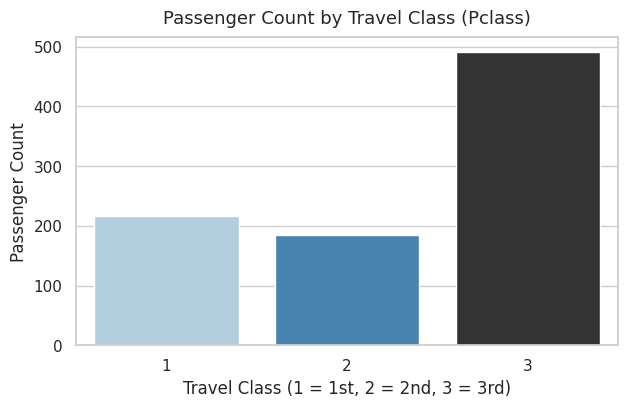

In [3]:
plt.figure(figsize=(7, 4))
sns.countplot(
    data=df, 
    x='Pclass', 
    palette='Blues_d', 
    hue='Pclass', 
    legend=False
)
plt.title('Passenger Count by Travel Class (Pclass)', fontsize=13, pad=10)
plt.xlabel('Travel Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Passenger Count')

# Save plot robustly
plot_dir = '../../outputs/plots' if os.path.exists('../../outputs/plots') else ('outputs/plots' if os.path.exists('outputs/plots') else '.')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'univariate_countplot_pclass.png'), dpi=150)
plt.show()


### 2.3 Bar Chart of Normalized Proportions

### What are we doing?
We display percentages instead of raw counts for the `Sex` feature to assess gender representation.


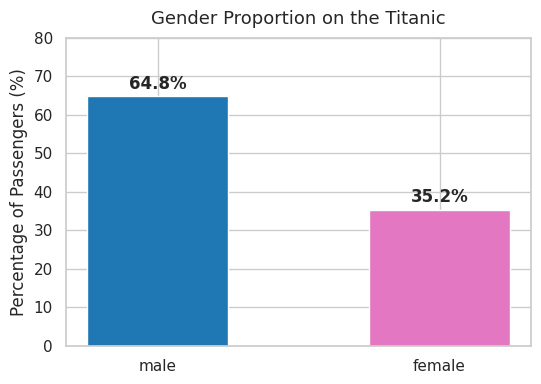

In [4]:
# Calculate percentage per gender
gender_pct = (df['Sex'].value_counts(normalize=True) * 100).round(2)

plt.figure(figsize=(6, 4))
bars = plt.bar(gender_pct.index, gender_pct.values, color=['#1f77b4', '#e377c2'], width=0.5)

# Annotate bars with percentage values
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.title('Gender Proportion on the Titanic', fontsize=13, pad=10)
plt.ylabel('Percentage of Passengers (%)')
plt.ylim(0, 80)
plt.show()


### 2.4 Pie Chart & Donut Chart (Proportion of Whole)

### What are we doing?
We visualize the share of embarkation ports using side-by-side Pie and Donut charts.


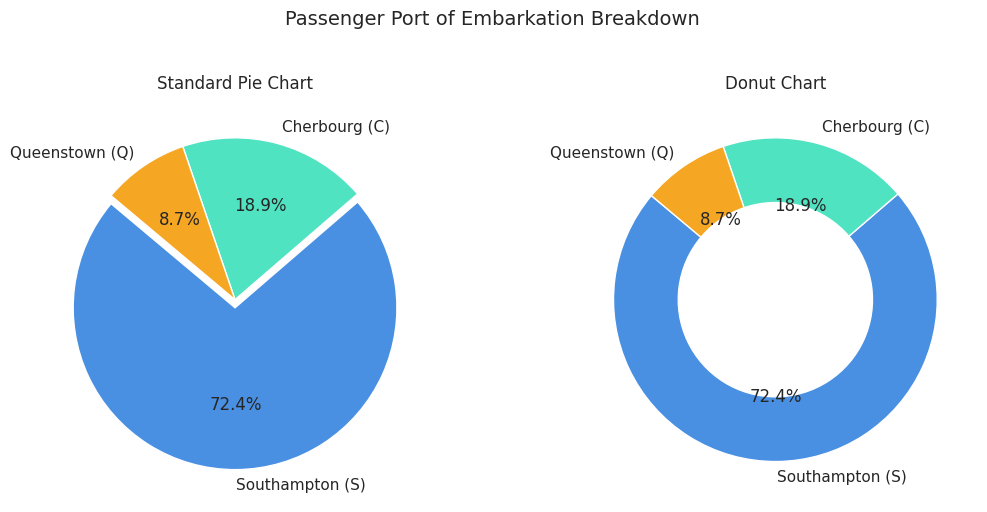

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

colors = ['#4A90E2', '#50E3C2', '#F5A623']
labels = ['Southampton (S)', 'Cherbourg (C)', 'Queenstown (Q)']
values = df['Embarked'].value_counts().values

# Standard Pie Chart
ax1.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, explode=(0.05, 0, 0))
ax1.set_title('Standard Pie Chart', fontsize=12)

# Donut Chart
wedges, texts, autotexts = ax2.pie(values, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors, wedgeprops=dict(width=0.4, edgecolor='w'))
ax2.set_title('Donut Chart', fontsize=12)

plt.suptitle('Passenger Port of Embarkation Breakdown', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 2.5 Pareto Chart (80/20 Rule)

### What are we doing?
We construct a Pareto chart combining individual category bars with a cumulative percentage line.

#### Why are we doing this?
Pareto analysis determines whether a small subset of categories represents the vast majority of observations (the 80/20 principle).


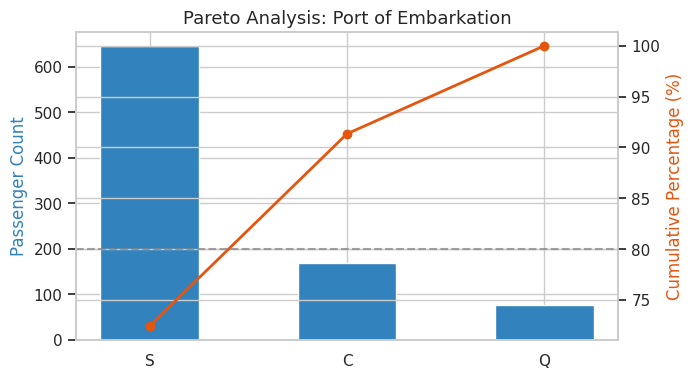

In [6]:
# Compute frequency and cumulative percentage for Embarked ports
pareto_df = df['Embarked'].value_counts().reset_index()
pareto_df.columns = ['Embarked', 'Count']
pareto_df['Cumulative_Pct'] = (pareto_df['Count'].cumsum() / pareto_df['Count'].sum()) * 100

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

ax1.bar(pareto_df['Embarked'], pareto_df['Count'], color='#3182bd', width=0.5)
ax2.plot(pareto_df['Embarked'], pareto_df['Cumulative_Pct'], color='#e6550d', marker='o', linewidth=2)

ax1.set_ylabel('Passenger Count', color='#3182bd')
ax2.set_ylabel('Cumulative Percentage (%)', color='#e6550d')
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7)
plt.title('Pareto Analysis: Port of Embarkation', fontsize=13)
plt.show()


## 3. Numerical Univariate Analysis

Numerical variables represent measurable numeric quantities. They divide into:
- **Discrete**: Countable integer values with fixed gaps (e.g. `SibSp`, `Parch`).
- **Continuous**: Real numbers measured on a continuous spectrum (e.g. `Age`, `Fare`).


In [7]:
# Discrete feature inspection
print("Unique SibSp (Family count - siblings/spouses):", sorted(df['SibSp'].unique()))

# Continuous feature range inspection
print(f"Age range:  {df['Age'].min():.1f} to {df['Age'].max():.1f} years")
print(f"Fare range: £{df['Fare'].min():.2f} to £{df['Fare'].max():.2f}")


Unique SibSp (Family count - siblings/spouses): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8)]
Age range:  0.4 to 80.0 years
Fare range: £0.00 to £512.33


### 3.1 Histograms & The Critical Role of Bin Width

### What are we doing?
We plot the distribution of passenger `Age` across 3 different bin choices (5 bins, 20 bins, 80 bins).

#### What does `sns.histplot()` do?
Divides the continuous range into adjacent non-overlapping intervals (bins) and plots the frequency count of values falling into each bin.

#### Important Parameter: `bins`
- Too few bins (under-binning): Oversimplifies the distribution, hiding multiple peaks (multimodality).
- Too many bins (over-binning): Creates artificial spikes and visual noise.
- Balanced bins (e.g., 20-30): Reveals true distribution shape.


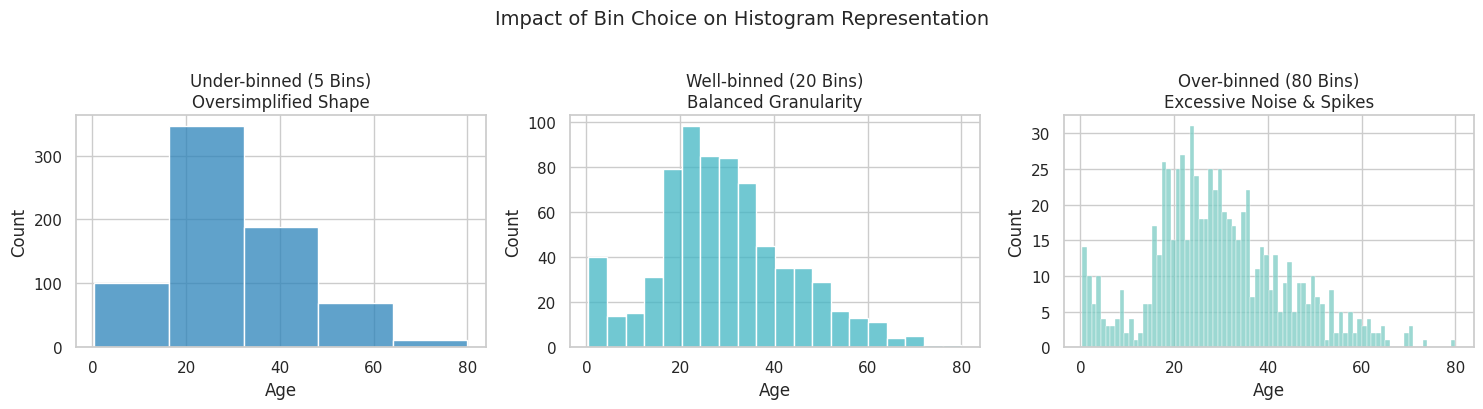

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Under-binned (5 bins)
sns.histplot(df['Age'], bins=5, ax=axes[0], color='#2b83ba')
axes[0].set_title('Under-binned (5 Bins)\nOversimplified Shape')

# Well-binned (20 bins)
sns.histplot(df['Age'], bins=20, ax=axes[1], color='#41b6c4')
axes[1].set_title('Well-binned (20 Bins)\nBalanced Granularity')

# Over-binned (80 bins)
sns.histplot(df['Age'], bins=80, ax=axes[2], color='#7bccc4')
axes[2].set_title('Over-binned (80 Bins)\nExcessive Noise & Spikes')

plt.suptitle('Impact of Bin Choice on Histogram Representation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 3.2 Kernel Density Estimation (KDE) with `sns.kdeplot()`

### What are we doing?
We overlay a smooth Kernel Density Estimate curve on top of the age histogram.

#### What does `kde=True` or `sns.kdeplot()` do?
Instead of hard discrete bins, KDE places a smooth continuous bell curve (kernel) over every data point and sums them, creating a continuous probability density estimate.

#### Why are we using it?
To visualize the continuous shape of the distribution independent of arbitrary bin boundaries.

#### What is the implication?
The curve reveals a prominent peak around young adulthood (20-30 years) with a small bump for infants (< 5 years).


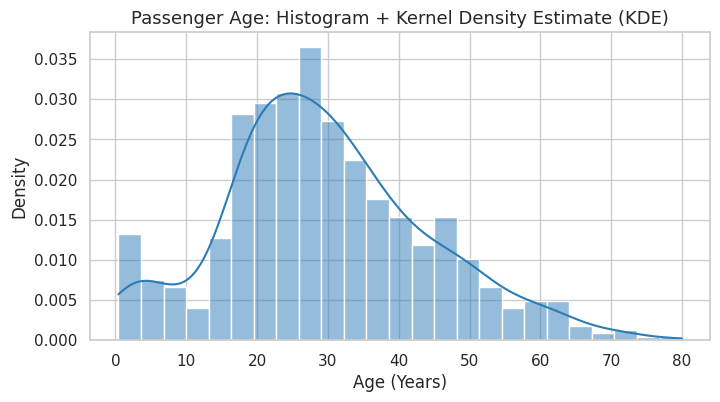

In [9]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], kde=True, bins=25, color='#2c7bb6', stat='density')
plt.title('Passenger Age: Histogram + Kernel Density Estimate (KDE)', fontsize=13)
plt.xlabel('Age (Years)')
plt.ylabel('Density')

# Save plot
plt.savefig(os.path.join(plot_dir, 'univariate_age_hist_kde.png'), dpi=150)
plt.show()


### 3.3 Box Plot & Five-Number Summary (`sns.boxplot()`)

### What are we doing?
We compute Tukey's five-number summary and visualize the distribution of `Age` using `sns.boxplot()`.

#### How does Tukey's Box Plot work?
1. **Median ($Q_2$)**: Center line inside the box.
2. **$Q_1$ (25th percentile)**: Left edge of the box.
3. **$Q_3$ (75th percentile)**: Right edge of the box.
4. **Interquartile Range ($IQR$)**: $IQR = Q_3 - Q_1$ (width of the box).
5. **Whiskers**: Extend to the lowest and highest values within $1.5 \times IQR$ from the box edges:
   - $\text{Lower Fence} = Q_1 - 1.5 \times IQR$
   - $\text{Upper Fence} = Q_3 + 1.5 \times IQR$
6. **Outliers (Fliers)**: Points plotted individually beyond the whiskers.


In [10]:
# Compute the five-number summary for Age
age_clean = df['Age'].dropna()

q1 = age_clean.quantile(0.25)
median = age_clean.median()
q3 = age_clean.quantile(0.75)
iqr = q3 - q1
lower_fence = max(age_clean.min(), q1 - 1.5 * iqr)
upper_fence = q3 + 1.5 * iqr

print("--- Age Five-Number Summary & Fences ---")
print(f"Minimum:       {age_clean.min():.1f}")
print(f"Q1 (25%):      {q1:.1f}")
print(f"Median (50%):  {median:.1f}")
print(f"Q3 (75%):      {q3:.1f}")
print(f"Maximum:       {age_clean.max():.1f}")
print(f"IQR:           {iqr:.1f}")
print(f"Upper Fence:   {upper_fence:.1f} years (values above this are flagged as fliers)")


--- Age Five-Number Summary & Fences ---
Minimum:       0.4
Q1 (25%):      20.1
Median (50%):  28.0
Q3 (75%):      38.0
Maximum:       80.0
IQR:           17.9
Upper Fence:   64.8 years (values above this are flagged as fliers)


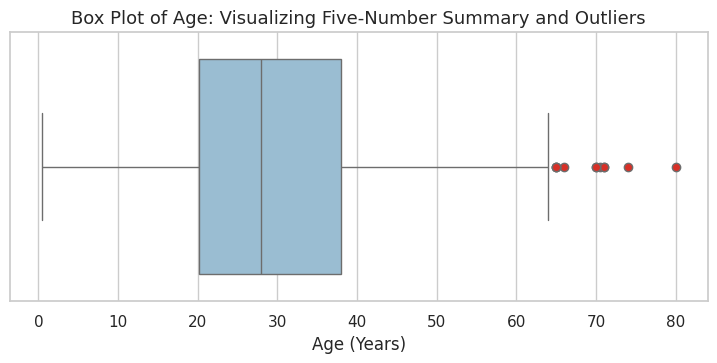

In [11]:
plt.figure(figsize=(9, 3.5))
sns.boxplot(
    x=df['Age'], 
    color='#91bfdb', 
    flierprops={'marker':'o', 'markerfacecolor':'#d73027', 'markersize':6}
)
plt.title("Box Plot of Age: Visualizing Five-Number Summary and Outliers", fontsize=13)
plt.xlabel("Age (Years)")
plt.show()


### 3.4 Outlier Analysis on `Fare`

### What are we doing?
We apply Tukey's $1.5 \times IQR$ fence rule to detect the exact number of extreme ticket prices in `Fare`.


In [12]:
q1_fare = df['Fare'].quantile(0.25)
q3_fare = df['Fare'].quantile(0.75)
iqr_fare = q3_fare - q1_fare
upper_fare_fence = q3_fare + 1.5 * iqr_fare

outlier_fares = df[df['Fare'] > upper_fare_fence]

print(f"Q1 Fare:         £{q1_fare:.2f}")
print(f"Q3 Fare:         £{q3_fare:.2f}")
print(f"IQR Fare:        £{iqr_fare:.2f}")
print(f"Upper Fence:     £{upper_fare_fence:.2f}")
print(f"Outliers Count:  {len(outlier_fares)} out of {len(df)} ({len(outlier_fares)/len(df)*100:.1f}%)")
print(f"Maximum Fare:    £{df['Fare'].max():.2f}")


Q1 Fare:         £7.91
Q3 Fare:         £31.00
IQR Fare:        £23.09
Upper Fence:     £65.63
Outliers Count:  116 out of 891 (13.0%)
Maximum Fare:    £512.33


### 3.5 Violin Plot (`sns.violinplot()`)

### What are we doing?
We plot a violin plot of `Age`.

#### What does `sns.violinplot()` do?
Combines a box plot with a rotated kernel density plot on each side.

#### Why are we using it?
A box plot only shows summary markers; it cannot show whether a distribution has multiple peaks. The violin plot reveals both summary quartiles and distribution shape simultaneously.


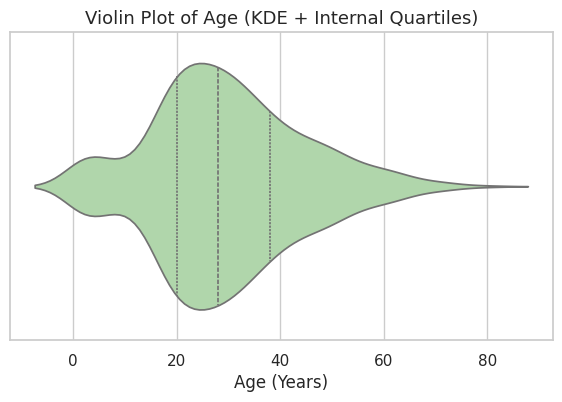

In [13]:
plt.figure(figsize=(7, 4))
sns.violinplot(x=df['Age'], color='#abdda4', inner='quartile')
plt.title('Violin Plot of Age (KDE + Internal Quartiles)', fontsize=13)
plt.xlabel('Age (Years)')
plt.show()


### 3.6 Empirical Cumulative Distribution Function (`sns.ecdfplot()`)

### What are we doing?
We plot the ECDF curve for `Fare`.

#### What does `sns.ecdfplot()` do?
Plots the proportion of data points less than or equal to each value $x$:
$$F_n(x) = \frac{1}{n} \sum_{i=1}^n \mathbb{I}(x_i \le x)$$

#### Why are we using it?
An ECDF requires no bin width choices and directly answers practical questions like "What percentage of passengers paid less than £50?"


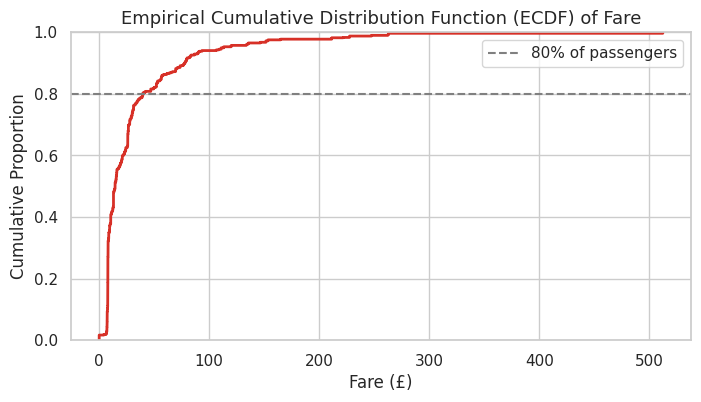

In [14]:
plt.figure(figsize=(8, 4))
sns.ecdfplot(data=df, x='Fare', color='#d73027', linewidth=2)
plt.axhline(0.80, color='gray', linestyle='--', label='80% of passengers')
plt.title('Empirical Cumulative Distribution Function (ECDF) of Fare', fontsize=13)
plt.xlabel('Fare (£)')
plt.ylabel('Cumulative Proportion')
plt.legend()
plt.show()


### 3.7 Strip Plot (`sns.stripplot()`)

### What are we doing?
We plot every individual passenger age as a dot with random vertical jitter.

#### What does `sns.stripplot()` do?
Draws a scatter plot where one variable is categorical (or a single axis) with slight jitter to prevent identical points from completely overlapping.

#### What is the implication?
Provides the most honest, raw view of data density, showing the heavy concentration between 18 and 35.


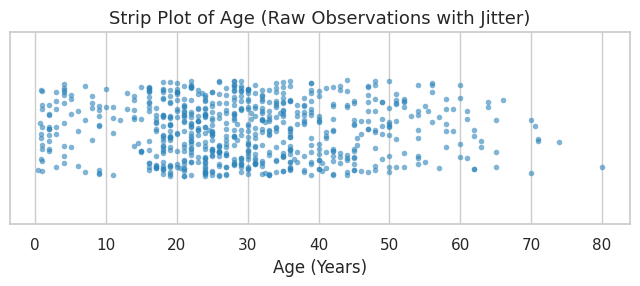

In [15]:
plt.figure(figsize=(8, 2.5))
sns.stripplot(x=df['Age'], jitter=0.25, size=4, color='#2b83ba', alpha=0.6)
plt.title('Strip Plot of Age (Raw Observations with Jitter)', fontsize=13)
plt.xlabel('Age (Years)')
plt.show()


## 4. Central Tendency & Dispersion Metrics

### What are we doing?
We define a helper function `compute_stats` to compute summary metrics and quantify distribution skewness.

#### What is this function?
`compute_stats(series, name)` calculates:
- Central tendency: `mean`, `median`, `mode`
- Dispersion: `std` (standard deviation), `IQR`
- Distribution shape: Fisher-Pearson coefficient of `skew`

#### Why did we create it?
To contrast the statistical behavior of symmetric features (`Age`) against heavily skewed features (`Fare`).

#### What does it take as input?
- `series` (pd.Series): The numerical feature to evaluate.
- `name` (str): Label for display.

#### What does it return?
A formatted Pandas DataFrame comparing the statistics.

#### How does it work?
It drops nulls, computes each statistic directly using Pandas methods, and returns a single summary table.

#### What is the implication?
For `Age`, Mean (29.7) $\approx$ Median (28.0), showing near symmetry (skew = +0.39).
For `Fare`, Mean (£32.2) $\gg$ Median (£14.5), showing extreme right-skewness (skew = +4.79).


In [16]:
def compute_stats(series, name):
    s = series.dropna()
    mean = s.mean()
    median = s.median()
    mode = s.mode()[0]
    std = s.std()
    q75, q25 = np.percentile(s, [75, 25])
    iqr = q75 - q25
    skew = s.skew()
    
    return pd.DataFrame({
        'Metric': ['Mean', 'Median', 'Mode', 'Std Dev', 'IQR', 'Skewness'],
        name: [round(mean, 2), round(median, 2), round(mode, 2), round(std, 2), round(iqr, 2), round(skew, 2)]
    }).set_index('Metric')

stats_comparison = pd.concat([compute_stats(df['Age'], 'Age'), compute_stats(df['Fare'], 'Fare')], axis=1)
stats_comparison


,Age,Fare
Metric,,
Mean,29.70,32.20
Median,28.00,14.45
Mode,24.00,8.05
Std Dev,14.53,49.69
IQR,17.88,23.09
Skewness,0.39,4.79


### 4.1 Mean vs. Median: Visualizing the Skew Pull

### What are we doing?
We plot the right-skewed distribution of `Fare` and overlay vertical lines for the Mean (red) and Median (green).

#### Why are we doing this?
To demonstrate that extreme outliers pull the Mean strongly to the right, while the Median remains robust and resistant to outliers.


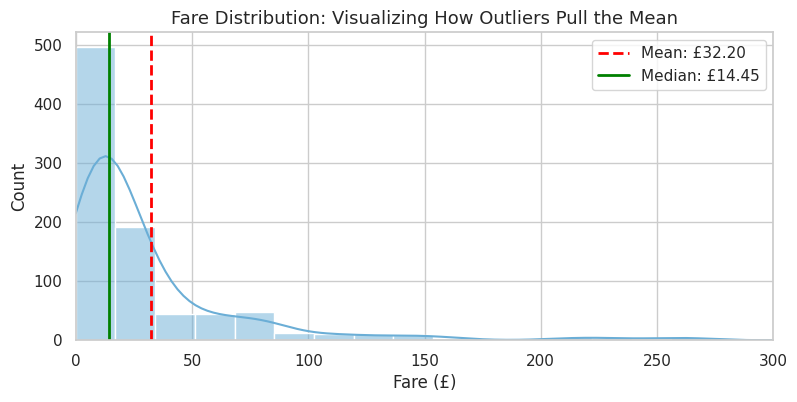

In [17]:
plt.figure(figsize=(9, 4))
sns.histplot(df['Fare'], bins=30, color='#6baed6', kde=True)

fare_mean = df['Fare'].mean()
fare_median = df['Fare'].median()

plt.axvline(fare_mean, color='red', linestyle='--', linewidth=2, label=f'Mean: £{fare_mean:.2f}')
plt.axvline(fare_median, color='green', linestyle='-', linewidth=2, label=f'Median: £{fare_median:.2f}')

plt.title('Fare Distribution: Visualizing How Outliers Pull the Mean', fontsize=13)
plt.xlabel('Fare (£)')
plt.ylabel('Count')
plt.xlim(0, 300)
plt.legend(fontsize=11)
plt.show()


---

## What We Learned
- **Categorical Profiling**: Evaluated class balance using frequency counts (`value_counts`), count plots (`sns.countplot`), proportions, and Pareto analysis.
- **Histogram Binning Sensitivity**: Learned that bin count controls whether real patterns are revealed or obscured.
- **KDE Smoothing**: Used `sns.kdeplot` to estimate continuous underlying probability densities without binning bias.
- **Tukey's $1.5 \times IQR$ Rule**: Derived box plot fences and identified outliers mathematically.
- **Violin Plots & ECDFs**: Combined density shape with quartiles (Violin) and observed percentile thresholds directly (ECDF).
- **Skew Pull**: Proved that extreme outliers pull the Mean far away from the Median, making Median the preferred measure of central tendency for skewed data.

---

## Important Takeaways
1. **Always pair histograms with box plots**: Histograms reveal peaks and shape; box plots isolate extreme values.
2. **Never report the Mean alone on skewed data**: If Skewness $> 1$, always report the Median alongside the Mean.
3. **Outliers are not automatically errors**: A £512 ticket is not corrupted data; it reflects genuine First Class luxury suites. Do not discard without domain context.

---

## Common Mistakes
1. **Using bar charts for continuous variables**: Bar charts are for categorical counts or category aggregates, not continuous distributions. Use histograms or KDEs.
2. **Over-interpreting noisy spikes in over-binned histograms**: Choosing 100 bins on 500 samples creates random spikes that look like multiple modes.
3. **Blindly trimming outliers**: Deleting data flagged by $1.5 \times IQR$ without investigating can discard the most informative instances in the dataset.

---

## Final Mental Model

```text
┌────────────────────────────────────────────────────────────────────────┐
│                      UNIVARIATE ANALYSIS TOOLKIT                       │
└────────────────────────────────────────────────────────────────────────┘
          │
          ├──► Categorical Variable ──► value_counts()
          │                         ──► sns.countplot() / Bar chart
          │                         ──► Pareto 80/20 analysis
          │
          └──► Numerical Variable   ──► Histogram (bin selection)
                                    ──► KDE curve (smooth shape)
                                    ──► Box plot (1.5*IQR outliers)
                                    ──► Violin plot (KDE + Box)
                                    ──► ECDF (cumulative percentiles)
                                    ──► Mean vs. Median comparison
```
